# Autocorrelación global



## Introducción

Los métodos de estadística espacial también se denominan **análisis exploratorio de datos espaciales (ESDA)**. Las estadística espacial comprende métodos para probar la existencia de procesos de autocorrelación espacial. Las medidas de autocorrelación espacial se utilizan para evaluar la correlación de variables con respecto a la ubicación espacial. 

**La autocorrelación espacial significa que las observaciones geográficamente cercanas son más similares entre sí que las distantes**. Esto hace posible predecir valores en un punto dado, conociendo los valores en otras ubicaciones. 

La medida de autocorrelación espacial se puede utilizar de varias formas: para **probar la existencia de autocorrelación** espacial y características de la población; para determinar el **grado de autocorrelación**, por ejemplo, la distancia por encima de la cual las observaciones son independientes; determinar el modelo teórico apropiado para la estructura espacial observada o concluir sobre el proceso espacial. 

Con base en las conclusiones de la ESDA, se puede **rechazar la hipótesis de la aleatoriedad espacial**, lo que abre el camino a la búsqueda de conglomerados espaciales (Anselin, 1999). Las conclusiones de la ESDA también son la base para la especificación espacial de los modelos.

### Estadístico de Autocorrelación: una forma general

**Medida de similaridad**

El producto vectorial: $y_iy_j$

-   Bajo aleatoriedad, el producto vectorial no es sistemáticamente grande o pequeño.
-   Cuando valores altos están sistemáticamente juntos, el producto vectorial será grande y vice versa. 

**Medidas de Disimilaridad**

Dos medidas comunides de disimilaridad son: 

1. diferencia al cuadrado $(y_i-y_j)^2$
2. diferencia absoluta $|y_i-y_j|$

-   Bajo aleatoriedad, la medida de disimilitud no es sistemáticamente grande o pequeño.
-   Cuando valores altos están sistemáticamente juntos, el producto vectorial será grande y vice versa. 


**Similaridad posicional**

Los pesos espaciales $w_{ij}$ formalizan la noción de vecinos (vecinos en algún sentido).



Una forma en que se puede plantear un estadístico general de autocorrelación como

> suma de todas las parejas del producto de una **medida de similaridad de la variable** y un **indicador de vecindad** (peso espacial)

$$
Estadístico = \sum_i\sum_jf(x_ix_j)w_{ij}
$$

donde $f(x_ix_j)$ denota una forma funcional de la similaridad entre $i$ y $j$ para la variable $x$. $w_{ij}$ es el peso espacial entre $i$ y $j$.


En estadística espacial se utilizan dos tipos de medidas: **medidas globales** y **locales**. 

Por un lado, las medidas globales se plasman en un indicador de autocorrelación espacial o similitud general de regiones. Su ventaja es que es un indicador sintética y su desventaja es promediar. 

Por otro lado, gracias a las estadísticas locales, que se determinan para cada región, se puede responder a la pregunta de **si la región está rodeada de regiones con valores altos o bajos o si es similar/diferente a las regiones vecinas**. Los valores de las estadísticas locales **no se generalizan para toda el área** analizada y se trabaja con información sobre la posición de cada región en relación con los vecinos.


El uso de técnicas ESDA es el **primer paso en el análisis de datos espaciales** y permite la detección de patrones de autocorrelación espacial globales y locales en los datos. 

La **autocorrelación global** se puede medir mediante las estadísticas I de Moran global (Moran, 1950; Cliff & Ord, 1981) y C de Geary. 

Las medidas locales más utilizadas incluyen las estadísticas locales Moran's II y las estadísticas locales Geary's Ci, que forman parte del llamado **indicador local de asociación espacial (LISA)** (Anselin, 1995) y las estadísticas locales G Getis-Ord (Ord & Getis, 1995). 

Las estadísticas globales pueden **identificar conglomerados y relaciones espaciales solo para todo el sistema**. Sin embargo, estas estadísticas se pueden desagregar en estadísticas locales, gracias a las cuales se pueden **detectar patrones de relaciones espaciales locales entre las regiones y sus vecinos**. 

El cálculo de LISA permite detectar cuál de las regiones influye fuertemente en la formación de conglomerados locales y examinar los conglomerados locales no aleatorios, los denominados puntos calientes/fríos (*hot spots* o *cold spots*), inestabilidad local (heterocedasticidad), observaciones atípicas significativas (Ministeri, 2003). La siguiente tabla resume algunas de las características listadas:


| Estadístico  | Tipo | Tipo de medición   | Interpretación| Funciones en `Python`|
|----------------------------|------------------|--------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------|
| Moran's I  | Global   | Una medida de autocorrelación espacial  | $I> 0$: autocorrelación   espacial positiva, los valores de observación a la distancia $d$ son similares <br/> $I <0$: autocorrelación espacial negativa, los valores de observación a la   distancia $d$ son diferentes <br/> $I = 0$: los valores de observación a la distancia d se distribuyen   aleatoriamente  | `from pysal.explore import esda`<br/>`esda.moran.Moran`<br/>`from splot.esda import plot_moran`|
| Geary’s C  | Global  | Una medida de autocorrelación espacial | $0 <C <1$: autocorrelación   espacial positiva, los valores de observación a la distancia $d$ son   similares   <br/>   $1 <C <2$: autocorrelación espacial negativa, los valores de   observación a la distancia $d$ son diferentes                                                                                   | `geary ()`<br/>      `geary.test ()`   <br/>   `geary.mc ()`                                                                    |
| Join-count                 | Global en grupos | Una medida de autocorrelación espacial                                   | $H_0$ asume que no hay   autocorrelación espacial, el valor $p>\alpha$ confirma esta hipótesis   <br/>   $H_1$ asume la existencia de autocorrelación espacial, valor $p <\alpha$   confirma esta hipótesis                                                                                                                 | `joincount.test ()`   <br/>   `joincount.mc ()`   <br/>   `joincount.multi ()`                                                  |
| Local   Moran’s $I_i$         | Local            | Junto con Local Geary, crea LISA, una medida de relaciones   espaciales. | valor $p <\alpha$: rodeado por   valores relativamente altos, un grupo de valores altos  <br/>    valor $p> (1-\alpha)$: un área rodeada por valores relativamente bajos, un grupo   de valores bajos                                                                                                                      | `local.moran ()` <br/>     `localmoran.sad ()`                                                                           |
| Local   Geary’s $C_i$         | Local            | Junto con Local Moran, crea LISA, una medida de diversidad   espacial    | valor $p> (1-\alpha)$: positivo,   región rodeada de observaciones similares      valor $p <\alpha$: negativo, región rodeada por diferentes observaciones                                                                                                                                                            | Existe el comando `usdm::lisa()`       que permite al usuario calcular este estadístico, pero para rásteres. |
| Local $G_i$, $G^*$             | Local            | Medida de relaciones espaciales                                          | $G_i> 0$: área rodeada por   valores relativamente altos, clúster de alto valor   <br/>   $G_i <0$: área rodeada por valores relativamente bajos, clúster de valor   bajo                                                                                                                                            | `localG ()`                                                                                                       |
| Local $H_i$,      LOSH     | Local            | Medida de relaciones espaciales                                          | Interpretado junto con las   estadísticas $G^*$. Valores altos indican un entorno heterogéneo; valores bajos   indican homogeneidad local.                                                                                                                                                                  | `LOSH()`                                                                                                          |
| Empirical      Bayes index | Local            | Medida de relaciones espaciales                                          | Interpretado como las   estadísticas I de Moran, utilizadas por interés (por ejemplo, número de casos   / población)                                                                                                                                                                                      | `EBImoran.mc()`                                                                                                   |
Table: Estadísticos espaciales globales y locales. Fuente: @kopczewska2020applied. ($\alpha$: nivel de significancia).


**Supuestos:**

La estadística espacial se basa en varios supuestos. El más importante de ellos es la **estacionariedad**, lo que significa que **los datos analizados deben tener una distribución normal con promedio y varianza constantes**. 

Sin embargo, las estructuras de autocorrelación espacial no siempre son constantes en toda el área de estudio, por lo que es suficiente satisfacer una **estacionariedad débil, donde la media y la varianza son constantes, mientras que la autocorrelación depende solo de la distancia entre los objetos probados**. 

Los patrones espaciales deben ser **isotrópicos**; es decir, **no deben depender de la dirección del estudio**. Además, la forma del área estudiada afecta la intensidad, alcance y tipo de proceso espacial estimado, así como su importancia. 

También existen los llamados efectos de borde (Fortin, Dale y Ver Hoef, 2002). Este problema se revela durante las observaciones en el borde del área de estudio. Estas **regiones tienen menos vecinos que los objetos ubicados en el medio**. Como resultado de este efecto, pueden aparecer diferencias en las estimaciones dependiendo de la matriz de vecindad adoptada (por ejemplo, de primer o segundo orden) (Cressie, 1993b).


Un elemento común en econometría espacial es el llamado retardo/rezago espacial, que se determina para la variable examinada. El operador de rezago espacial es un **promedio ponderado del valor de la variable en las regiones vecinas, de acuerdo con la matriz de ponderaciones espaciales declarada** $W$. 

Cuando se utiliza la matriz de vecindad de primer orden para el cálculo según el criterio de contigüidad, el rezago espacial será el promedio de los valores en las regiones limítrofes con el área examinada. Si se adoptara la matriz de segundo orden, el rezago espacial se determinaría a partir de los valores de los vecinos de estos vecinos. Una interpretación análoga ocurre cuando se usa la matriz de distancia o la matriz $k$ de los vecinos más cercanos.

### Ideas centrales

La noción de autocorrelación espacial hace referencia a la existencia de una *relación funcional entre lo que sucede en un punto del espacio y lo que ocurre en otros lugares cercanos* (Anselin, 1988). En términos simples, se trata de analizar en qué medida la similitud de los valores entre observaciones está asociada con la cercanía geográfica entre esas observaciones.

Este concepto se asemeja al de la correlación convencional entre dos variables, que nos indica cómo cambia una variable en función de otra. Sin embargo, en el caso espacial, la relación es entre los valores de una misma variable en diferentes ubicaciones. De forma análoga a la autocorrelación temporal —donde se relacionan valores de una variable en distintos momentos del tiempo—, la autocorrelación espacial relaciona valores en distintos puntos del espacio.

Otra manera de interpretar este concepto es entender que la autocorrelación espacial mide cuánta información aporta el valor de una variable en una ubicación específica sobre los valores de esa misma variable en ubicaciones vecinas.

### Comprensión de la Autocorrelación Espacial

Para entender mejor la autocorrelación espacial, es útil comenzar por imaginar un mundo sin ella. En este contexto surge la idea de **aleatoriedad espacial**: una situación en la que la localización de una observación no proporciona ninguna información sobre su valor. Es decir, una variable es espacialmente aleatoria si no sigue un patrón geográfico discernible. De esta forma, la autocorrelación espacial puede definirse como la *ausencia de aleatoriedad espacial*.

Sin embargo, esta definición sigue siendo general. Para especificarla mejor, la autocorrelación espacial suele clasificarse en dos dimensiones principales: **signo** y **escala**.

- **Signo**:
  - *Positiva*: valores similares se encuentran cerca unos de otros. No importa si son valores altos o bajos; lo relevante es que hay una asociación positiva entre cercanía espacial y similitud. Por ejemplo, zonas con altos ingresos tienden a estar próximas a otras similares, y lo mismo ocurre con zonas de pobreza.
  - *Negativa*: valores similares se encuentran alejados entre sí. Este patrón puede observarse en fenómenos como la competencia espacial o en la planificación de infraestructura, donde se busca una cobertura geográfica eficiente (por ejemplo, hospitales o supermercados de distintas marcas).

- **Escala**:
  - *Global*: se refiere al patrón general de agrupamiento de valores en todo el conjunto de datos espaciales. Este capítulo se centra en este tipo de análisis.
  - *Local*: estudia las desviaciones de los patrones globales a escalas más pequeñas o zonas específicas. Este enfoque será tratado en el próximo capítulo.



En las siguientes secciones usaremos datos de Valor agregado anual por cantones del Ecuador tomados del [Banco Central del Ecuador](https://contenido.bce.fin.ec/docs.php?path=/documentos/Estadisticas/SectorReal/CuentasCantonales/Indice.htm) y el indicador de Necesidades Básicas Insatisfechas por personas. 

### Una aplicación: el valor agregado bruto y la pobreza por necesidades insatisfechas
Para leer los datos de un archivo `shp` de github usaremos la función `read_git_shp`:

In [166]:
import requests
from io import BytesIO
import zipfile
import geopandas as gpd
import tempfile
import os

def read_git_shp(nombre, url):
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"Error al descargar shapefile: {response.status_code}")
    
    zip_bytes = BytesIO(response.content)

    with zipfile.ZipFile(zip_bytes, "r") as z:
        shp_files = [f for f in z.namelist() if f.endswith(nombre + ".shp")]
        if not shp_files:
            raise FileNotFoundError(f"No se encontró {nombre}.shp en el zip")
        
        shp_name = shp_files[0]
        with tempfile.TemporaryDirectory() as tmpdirname:
            z.extractall(tmpdirname)
            gdf = gpd.read_file(os.path.join(tmpdirname, shp_name))
    return gdf

# Uso correcto
url = "https://github.com/vmoprojs/DataLectures/raw/master/SpatialData/SHP.zip"
df = read_git_shp("nxprovincias", url)


Ahora importamos el valor agregado anual por cantones del Ecuador tomados del Banco Central del Ecuador y el indicador de Necesidades Básicas Insatisfechas por personas. 

In [168]:
import pandas as pd
import geopandas as gpd
import requests
import zipfile
import io
import os

# 1. Leo los datos del VAB no petrolero por cantones 2007-2019
url_vab = "https://raw.githubusercontent.com/vmoprojs/DataLectures/master/SpatialData/VABNoPetroleroCantones2007-2019.csv"
datos = pd.read_csv(url_vab, sep=",")

# 2. Relleno con 0 los códigos de cantón que solo tienen 3 caracteres (para normalizar a 4 dígitos)
datos['COD_CANT'] = datos['COD_CANT'].astype(str)
datos.loc[datos['COD_CANT'].str.len() == 3, 'COD_CANT'] = '0' + datos.loc[datos['COD_CANT'].str.len() == 3, 'COD_CANT']

# 3. Filtrar los datos para el año 2019
datos = datos[datos['YEAR'] == 2019]

# 4. Leo los datos de población proyectada 2010–2020
url_poblacion = "https://raw.githubusercontent.com/vmoprojs/DataLectures/master/SpatialData/proyeccion_cantonal_total_2010-2020.csv"
poblacion = pd.read_csv(url_poblacion, sep=";")

# 5. Normalizo los códigos de cantón para que tengan 4 caracteres (agregando un 0 a los que tienen 3)
poblacion['CODIGO'] = poblacion['CODIGO'].astype(str)
poblacion.loc[poblacion['CODIGO'].str.len() == 3, 'CODIGO'] = '0' + poblacion.loc[poblacion['CODIGO'].str.len() == 3, 'CODIGO']

# 6. Leo los datos de Necesidades Básicas Insatisfechas (NBI)
url_nbi = "https://raw.githubusercontent.com/vmoprojs/DataLectures/master/SpatialData/NBI_PER_CANT.csv"
nbi = pd.read_csv(url_nbi, sep=";")

# 7. Normalizo los códigos de cantón
nbi['CODIGO'] = nbi['CODIGO'].astype(str)
nbi.loc[nbi['CODIGO'].str.len() == 3, 'CODIGO'] = '0' + nbi.loc[nbi['CODIGO'].str.len() == 3, 'CODIGO']


# 8. Uno los datos de población a los datos económicos usando el código de cantón
datos = datos.merge(poblacion[['CODIGO', 'A_2019']], left_on='COD_CANT', right_on='CODIGO', how='left')


# 9. Uno los datos de pobreza (NBI) a los datos existentes
datos = datos.merge(nbi[['CODIGO', 'POBRES_P']], left_on='COD_CANT', right_on='CODIGO', how='left')

# 10. Calculo el VAB per cápita: VAB dividido por la población proyectada en 2019
datos['VAB_PC'] = datos['VAB'] / datos['A_2019']  # miles de USD por persona

# 11. Descargo y leo el shapefile con los polígonos cantonales
url = "https://github.com/vmoprojs/DataLectures/raw/master/SpatialData/2012_nxcantones.zip"
poligonos = read_git_shp("nxcantones",url)

Una vez extraida la información y el shapefile, quitamos a Galápagos y juntamos los datos a `poligonos`

In [170]:

# 1. Filtro para excluir la provincia "90"
poligonos = poligonos[poligonos['DPA_PROVIN'] != "90"]

# 2. Filtro para excluir la provincia "20"
poligonos = poligonos[poligonos['DPA_PROVIN'] != "20"]


# 3. Hacer el merge entre los polígonos y los datos económicos por cantón
# Se usa la columna 'DPA_CANTON' del shapefile y 'COD_CANT' del DataFrame 'datos'
poligonos = poligonos.merge(datos, left_on='DPA_CANTON', right_on='COD_CANT', how='left')

# 4. Eliminar las filas que tienen valores faltantes en la variable 'POBRES_P'
# Esto equivale a quedarse solo con los cantones que tienen datos de pobreza
poligonos = poligonos[~poligonos['POBRES_P'].isna()]

#poligonos['POBRES_P'].isna()

In [171]:
poligonos.columns

Index(['DPA_VALOR', 'DPA_ANIO', 'DPA_CANTON', 'DPA_DESCAN', 'DPA_PROVIN',
       'DPA_DESPRO', 'geometry', 'NOM_PROV', 'COD_PROV', 'NOM_CANT',
       'COD_CANT', 'PRODUCCION', 'CONSUMO_INTERMEDIO', 'VAB', 'YEAR', 'TIPO',
       'CODIGO_x', 'A_2019', 'CODIGO_y', 'POBRES_P', 'VAB_PC'],
      dtype='object')

<Axes: >

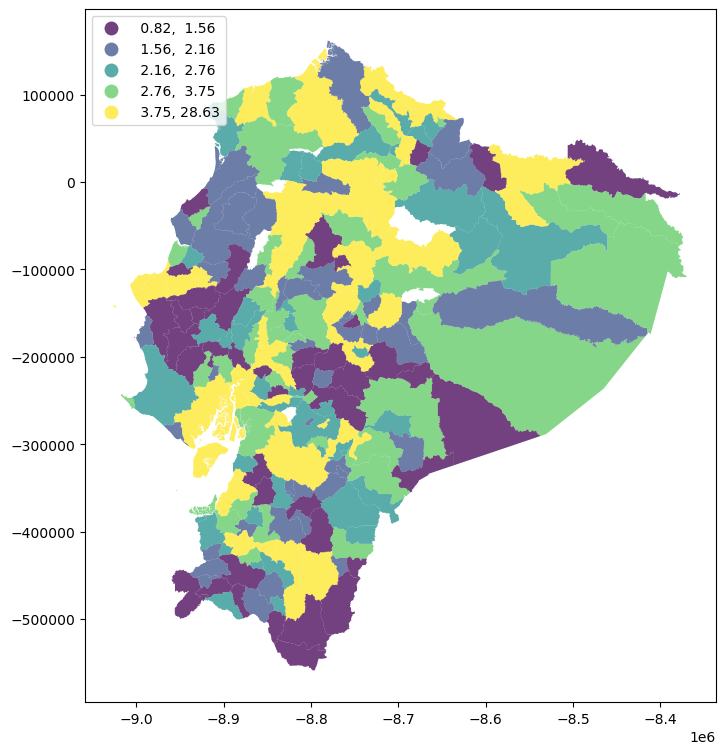

In [172]:
import matplotlib.pyplot as plt


# Reproyección a Web Mercator para usar contextily
poligonos = poligonos.to_crs(epsg=3857)

f, ax = plt.subplots(1, figsize=(9, 9))
poligonos.plot(
    column="VAB_PC",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=ax,
)

Antes de analizar la autocorrelación espacial, es fundamental definir la matriz de pesos espaciales. En este caso, se adopta el **criterio de los ocho vecinos más cercanos** como referencia, aunque, como se mencionó anteriormente, existen múltiples formas válidas de construir esta matriz. Para garantizar la comparabilidad entre unidades, los pesos se estandarizan por filas.

In [174]:
import geopandas as gpd
from libpysal.weights import Queen
from libpysal.weights import W

# 1. Construir la lista de vecinos usando contigüidad tipo Reina (equivalente a poly2nb)
# El parámetro silence_warnings=True es útil si hay geometrías sin vecinos
w_queen = Queen.from_dataframe(poligonos, silence_warnings=True,use_index=True)

# 2. Convertir la lista de vecinos a una matriz de pesos estilo "W" (filas normalizadas)
# Esto equivale a nb2listw(..., style="W") en R
# No hace falta especificar "zero.policy = TRUE" porque libpysal ignora por defecto las unidades sin vecinos
w_queen.transform = 'R'  # "R" es row-standardized (igual que "W" en R/spdep)

# Si deseas acceder directamente a la matriz de pesos como un diccionario:
weights_matrix = w_queen.full()  # O usar .neighbors y .weights para listas directas

# También puedes verificar qué observaciones no tienen vecinos:
islands = w_queen.islands  # Lista de índices (cantones) sin vecinos
islands

[27, 61, 94, 100, 102, 106, 116, 117, 121, 133, 187, 188, 214]

## Estadísticos Globales


Las medidas globales en estadística espacial permiten determinar la tendencia espacial general en la región. Su análisis permite una visión sintética de los datos. También proporcionan una buena base para una evaluación posterior más detallada del fenómeno.

### Retardo Espacial (Spatial Lag)

El operador de retardo espacial es una de las aplicaciones más comunes y directas de las matrices de pesos espaciales (denotadas formalmente como $\textbf{W}$) en el análisis espacial. Matemáticamente, se define como el producto entre la matriz de pesos espaciales y el vector de una variable dada.

Desde una perspectiva conceptual, el retardo espacial representa el comportamiento de una variable en el entorno inmediato de cada ubicación. En ese sentido, puede entenderse como un suavizador local, ya que resume el valor promedio del entorno.

Podemos expresar esto formalmente en notación matricial como:

$$
Y_{sl} = \textbf{W} Y
$$

O, de manera individual:

$$
y_{sl-i} = \sum_j w_{ij} y_j
$$

donde $w_{ij}$ es la celda en la fila $i$ y columna $j$ de la matriz $\textbf{W}$, representando la relación espacial entre las observaciones $i$ y $j$. Así, $y_{sl-i}$ captura el efecto de los valores vecinos ponderados por los pesos correspondientes.

En los casos donde $\textbf{W}$ es binaria, el retardo espacial es simplemente la suma de los valores de los vecinos. Si $\textbf{W}$ está estandarizada por filas (una transformación común), los pesos $w_{ij}$ estarán entre 0 y 1, y el retardo espacial se convierte en un *promedio local* del valor de $Y$ para cada observación $i$.

Este promedio local es precisamente el que se utilizará para el análisis de autocorrelación espacial en las siguientes secciones.

Como veremos a lo largo del libro, el retardo espacial es un componente clave en muchas técnicas de análisis espacial, y está completamente implementado en la biblioteca `PySAL`.

Por ejemplo, para calcular el retardo espacial de una variable como `VAB_PC`, se puede hacer mediante código como el siguiente:





In [176]:
poligonos["VAB_PC_lag"] = weights.spatial_lag.lag_spatial(
    w_queen, poligonos["VAB_PC"]
)

Veamos dos elementos de lo que hemos calculado:

In [178]:
poligonos.loc[[0, 1], ["DPA_DESCAN","VAB_PC", "VAB_PC_lag"]]

,DPA_DESCAN,VAB_PC,VAB_PC_lag
0,GUARANDA,3.602965,2.671548
1,CHILLANES,1.473314,2.266083


Veamos la variable y su rezago en mapas:

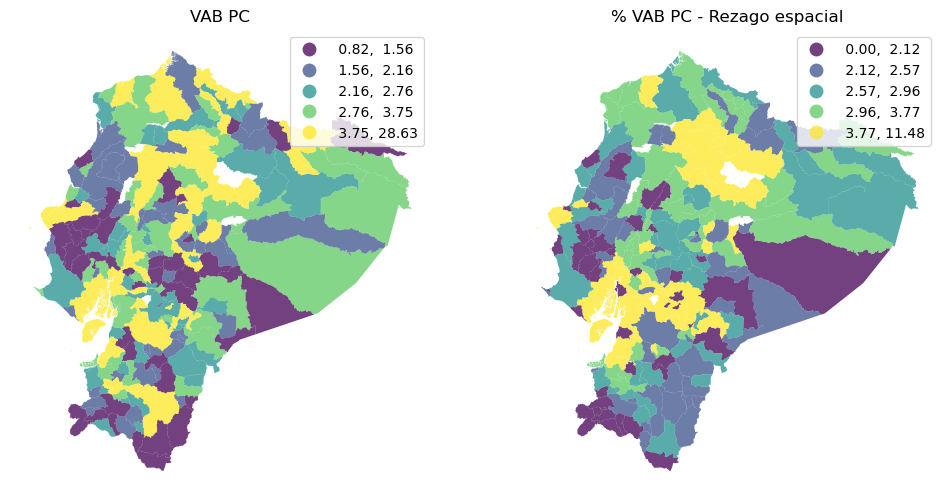

In [197]:
f, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1, ax2 = axs

poligonos.plot(
    column="VAB_PC",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    ax=ax1,
)
ax1.set_axis_off()
ax1.set_title("VAB PC")


poligonos.plot(
    column="VAB_PC_lag",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    ax=ax2,
)
ax2.set_axis_off()
ax2.set_title("% VAB PC - Rezago espacial")

plt.show()

**Mapa Izquierdo VAB PC (Valor Agregado Bruto per cápita)**

Este mapa representa el nivel de desarrollo económico per cápita por cantón.

- **Colores**:
  - 🟣 Morado oscuro: Valores bajos de VAB PC (0.82 - 1.56)
  - 🟢 Verde claro a 💛 Amarillo: Valores más altos (hasta 28.63)

- **Interpretación**:
  - Existen **diferencias regionales** notables en el VAB per cápita.
  - Los **cantones con mayor desarrollo económico** (amarillo) se concentran en algunas zonas de la Sierra Central y la Costa.
  - Los **cantones más rezagados** (morado) se encuentran en varias regiones dispersas, especialmente al sur y este del país.

**Mapa Derecho: % VAB PC - Rezago Espacial**

Este mapa muestra el **efecto del rezago espacial del VAB PC**, es decir, cuánto influye el VAB PC de los cantones vecinos sobre un cantón dado.

- **Colores**:
  - 🟣 Morado: Bajo rezago espacial (0.00 - 2.12)
  - 💛 Amarillo: Alto rezago espacial (3.77 - 11.48)

- **Interpretación**:
  - Los **cantones en amarillo** están **fuertemente influenciados** por sus vecinos, lo que sugiere posibles efectos de **contagio económico o spillover**.
  - Las zonas en morado muestran **menor integración económica regional**, lo que puede indicar **aislamiento** o **autonomía económica**.
  - Hay **rezagos espaciales altos** en sectores de la Amazonía y la Costa.

**Conclusiones Generales**

- Se evidencian **desigualdades territoriales** en el desarrollo económico.
- El rezago espacial permite identificar **interdependencias regionales**:
  - Un cantón con bajo VAB PC puede beneficiarse de sus vecinos si estos tienen altos niveles de desarrollo.
- Este análisis es clave para orientar **políticas de desarrollo territorial y planificación regional** más efectivas.


### Estadístico global: $I$ de Moran

El estadístico global $I$ de Moran es probablemente la medida espacial más antigua, introducida por Moran en 1950 (@moran1950notes) y se usa para realizar pruebas de hipótesis de autocorrelación global.

Es una prueba basada en la covarianza, similar a una prueba de Pearson y el estadístico tiene la siguiente fórmula:

<!-- $$ -->
<!-- I = \frac{\sum_i\sum_jw_{ij}(x_i-\bar{x})(x_j-\bar{x})}{S^2\sum_i\sum_jw_{ij}} -->
<!-- $$ -->
<!-- y -->

<!-- $$ -->
<!-- S^2 = \frac{1}{n}\sum_i(x_i-\bar{x})^2 -->
<!-- $$ -->

<!-- donde $x_i$ es la observación en la unidad espacial $i$, $\bar{x}$ es el promedio de todas las unidades espaciales, $n$ es el total de unidades espaciales y $w_{ij}$ es un elemento  de la matriz de pesos espaciales $W$. La matriz de pesos espaciales $W$ se suele **estandarizar por fila**. -->


$$
I = \frac{\sum_i\sum_jw_{ij}z_iz_j/S_0}{\sum_iz_i^2/n}
$$

donde $z_i = x_i-\bar{x}$, $S_0=\sum_i\sum_jw_{ij}$. $x_i$ es la observación en la unidad espacial $i$, $\bar{x}$ es el promedio de todas las unidades espaciales, $n$ es el total de unidades espaciales y $w_{ij}$ es un elemento  de la matriz de pesos espaciales $W$. La matriz de pesos espaciales $W$ se suele **[estandarizar por fila](https://desktop.arcgis.com/es/arcmap/latest/tools/spatial-statistics-toolbox/spatial-weights.htm)** (las filas suman $1$).

#### Inferencia

La significancia de estadístico $I$ de Moran puede evaluarse desde un enfoque paramétrico o no paramétrico; en este texto se adopta el enfoque no paramétrico. Para este objetivo se obtiene una distribución de la permutación del estadístico basado en una **simulación de Monte Carlo** de 10000 permutaciones. 

La **hipótesis nula** asumida es la ausencia de autocorrelación, es decir, una distribución aleatoria de los valores.